In [1]:
library(Seurat)
library(dplyr)

Loading required package: SeuratObject

Loading required package: sp

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays: Please run: options(Seurat.object.assay.version = 'v5')


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


In [2]:
sc_input <- readRDS('/data/work/MP/scRNA/scRNA_total.rds')

In [2]:
Epithelial <- readRDS('/data/work/MP/scRNA/Epithelial_subtypes.rds')

In [4]:
Idents(sc_input) <- sc_input$`total_cell_type_res_0.5`
Epithelial <- subset(sc_input, idents = c('Epithelial cells'))

In [5]:
DefaultAssay(Epithelial) <- "RNA"

In [ ]:
Idents(Epithelial) <- Epithelial$`orig.ident`
# Data preprocessing and dimensionality reduction
Epithelial_obj_list <- SplitObject(Epithelial, split.by = "orig.ident")

In [ ]:
# NormalizeData
for (name in names(Epithelial_obj_list)) {
   
    Epithelial_obj_list[[name]] <- NormalizeData(Epithelial_obj_list[[name]], normalization.method = "LogNormalize", assay = "RNA")

    Epithelial_obj_list[[name]] <- FindVariableFeatures(Epithelial_obj_list[[name]], assay = "RNA", nfeatures = 2000, selection.method = "vst")
}

integrated_features <- SelectIntegrationFeatures(object.list = Epithelial_obj_list)

Epithelial_obj_list <- lapply(X = Epithelial_obj_list, FUN = function(x) {
    x <- ScaleData(x, features = integrated_features, verbose = FALSE)
    x <- RunPCA(x, features = integrated_features, verbose = FALSE)
})

In [ ]:
####cca
anchors <- FindIntegrationAnchors(object.list = Epithelial_obj_list, anchor.features = integrated_features, reduction = "cca")

Epithelial <- IntegrateData(anchorset = anchors, normalization.method = "LogNormalize")

variable_feature <- rownames(Epithelial)
Epithelial <- ScaleData(Epithelial, features = variable_feature, vars.to.regress = c("nCount_RNA"))
options(repr.plot.width = 9, repr.plot.height = 9)
DefaultAssay(Epithelial) <- "integrated"

In [ ]:
# PCA

Epithelial <- RunPCA(Epithelial, assay = "integrated", verbose = T) 
Epithelial <- FindNeighbors(Epithelial, dims = 1:30, reduction = "pca")
# FindClusters
Epithelial <- RunUMAP(Epithelial, dims = 1:30, verbose = T )

In [ ]:
library("tidyverse")
library("cowplot")
library("patchwork")

In [ ]:
for (i in c(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2)) {
  Epithelial <- FindClusters(Epithelial, resolution = i)
  print(DimPlot(Epithelial, reduction = "umap", label = T) + labs(title = paste0("resolution: ", i)))
}

In [7]:
options(repr.plot.width = 15, repr.plot.height = 9)

In [13]:
cell_colors <- c(
'AT2 Epi' = '#FECF67', #FABDBB
'KRT18+ transitional Epi' = '#E45A5F',
'Repairing AT2 Epi' = '#B2E5FB',
'Tuft Epi' = '#e1a4c6',      
'stressed Epi' = '#c7deef',
'Airway basal Epi' = '#684797',
'intermediate Epi' ='#B94992',    
'SPP1+ Epi' = '#e0bc58',
'others' = '#7587b1',   
"Mesothelial-like" = "#74a893",
'Ciliated Epi' = '#edeaa4'   
)

In [19]:
library(ggplot2)

In [5]:
table(Epithelial$Epi_subtype_res_0.3)


                AT2 Epi KRT18+ transitional Epi       Repairing AT2 Epi 
                    639                     455                     451 
               Tuft Epi            stressed Epi        Airway basal Epi 
                    254                     135                     134 
       intermediate Epi               SPP1+ Epi                  others 
                    121                     112                     110 
       Mesothelial-like            Ciliated Epi 
                    100                      93 

In [23]:
Idents(Epithelial) <- "Epi_subtype_res_0.3"
table(Idents(Epithelial), Epithelial$orig.ident)
Cellratio2 <- prop.table(table(Idents(Epithelial), Epithelial$orig.ident), margin = 2)
Cellratio2 <- as.data.frame(Cellratio2)
colnames(Cellratio2) <- c("celltype","sample","ratio") 

                         
                          control-10XSC3 model-10XSC3
  AT2 Epi                            439          200
  KRT18+ transitional Epi            282          173
  Repairing AT2 Epi                  260          191
  Tuft Epi                           176           78
  stressed Epi                        10          125
  Airway basal Epi                    61           73
  intermediate Epi                    82           39
  SPP1+ Epi                           12          100
  others                              85           25
  Mesothelial-like                    84           16
  Ciliated Epi                        54           39

In [25]:
library(ggalluvial)

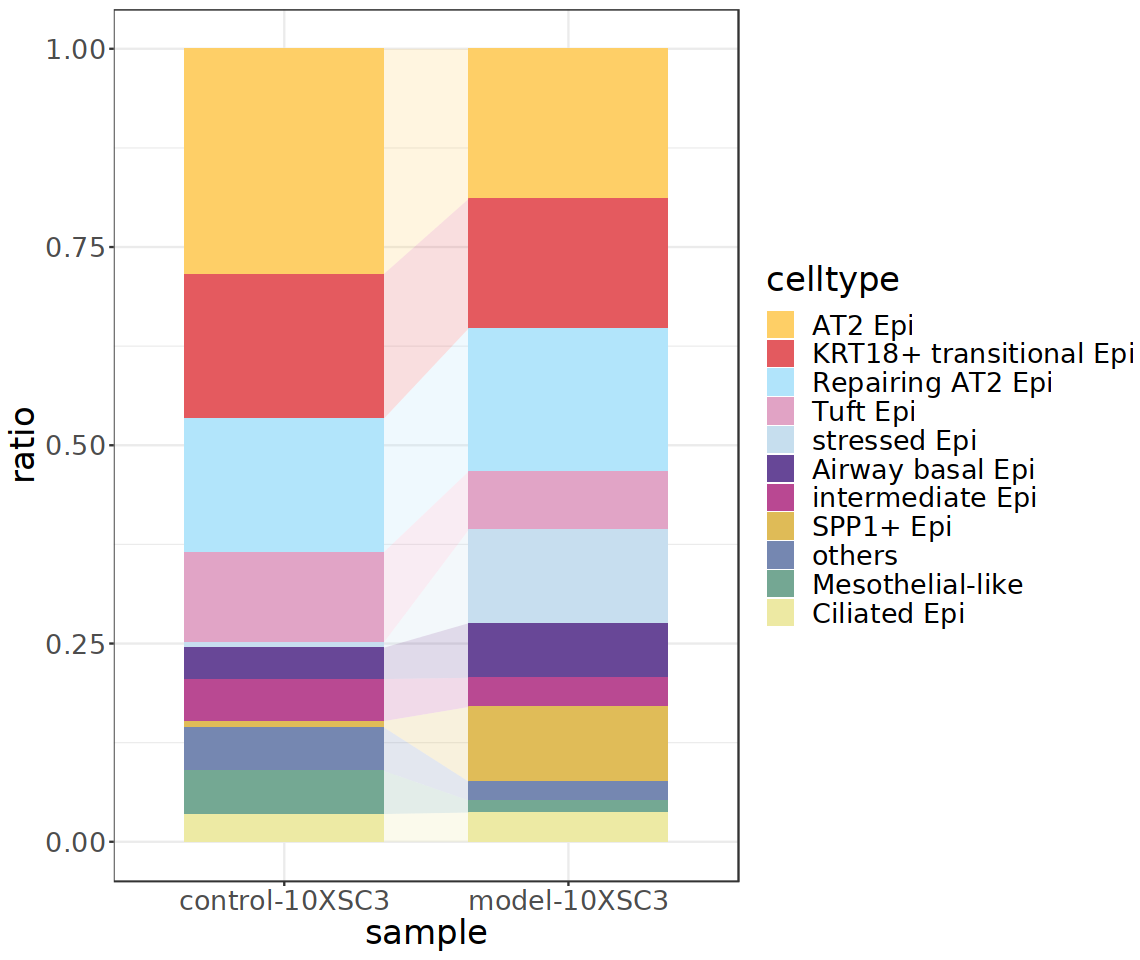

In [32]:
Cellratio2$celltype <- as.factor(Cellratio2$celltype)

# 画图
ggplot(Cellratio2, aes(x = sample, y = ratio, fill = celltype, stratum = celltype, alluvium = celltype)) +
  geom_col(width = 0.7, color = NA) +
  geom_flow(stat = "alluvium", width = 0.7, alpha = 0.2, knot.pos = 0) +
  scale_fill_manual(values = cell_colors) +
  theme_bw()+ theme(text=element_text(size= 20 )) 
ggsave("/data/work/MP/scRNA/Epithelial_subtypes_ratio.pdf",bg = "transparent", width =9, height =8)

In [16]:
options(repr.plot.width = 9.5, repr.plot.height = 8)

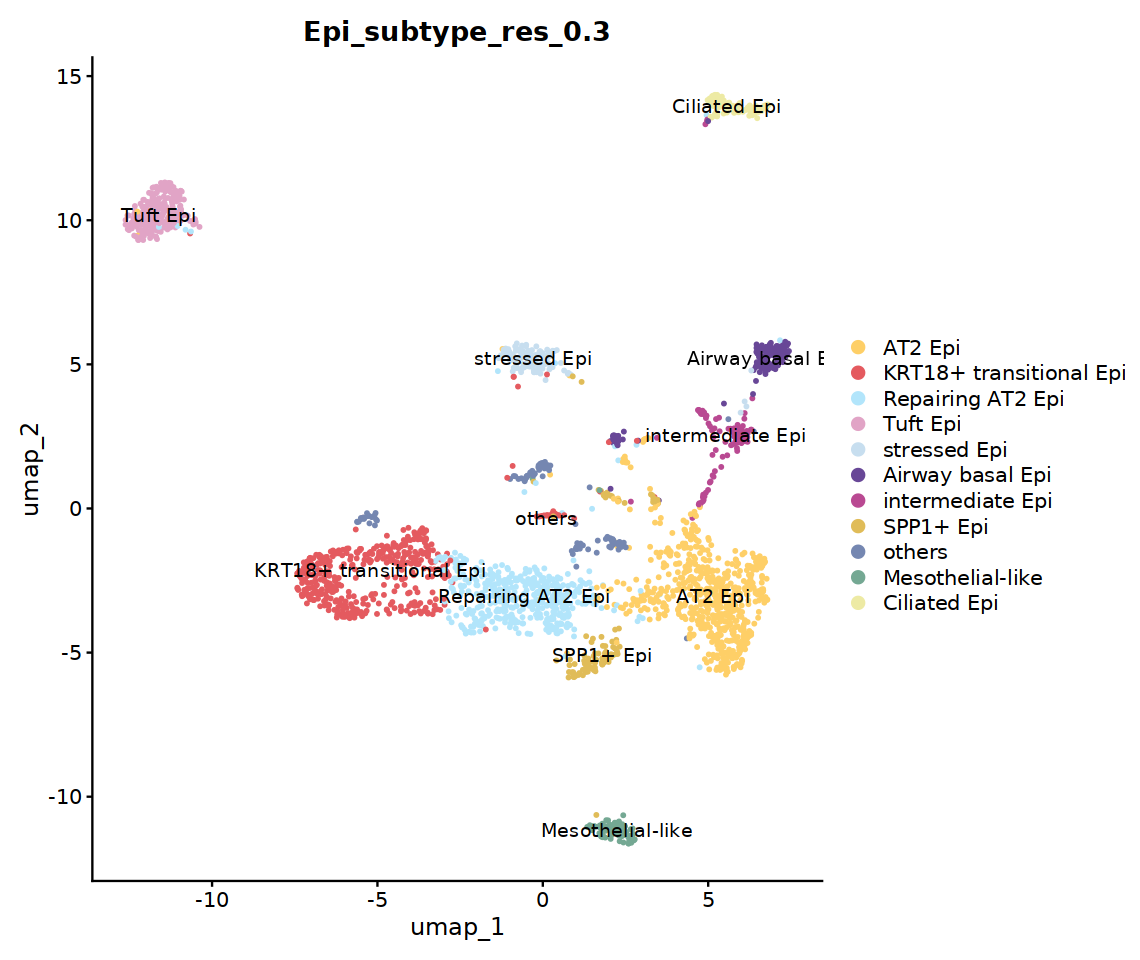

In [20]:
DimPlot(Epithelial, reduction = "umap", label = T,group.by = "Epi_subtype_res_0.3",cols =cell_colors)
ggsave("/data/work/MP/scRNA/Epithelial_subtypes.pdf",bg = "transparent", width =9.5, height =8)

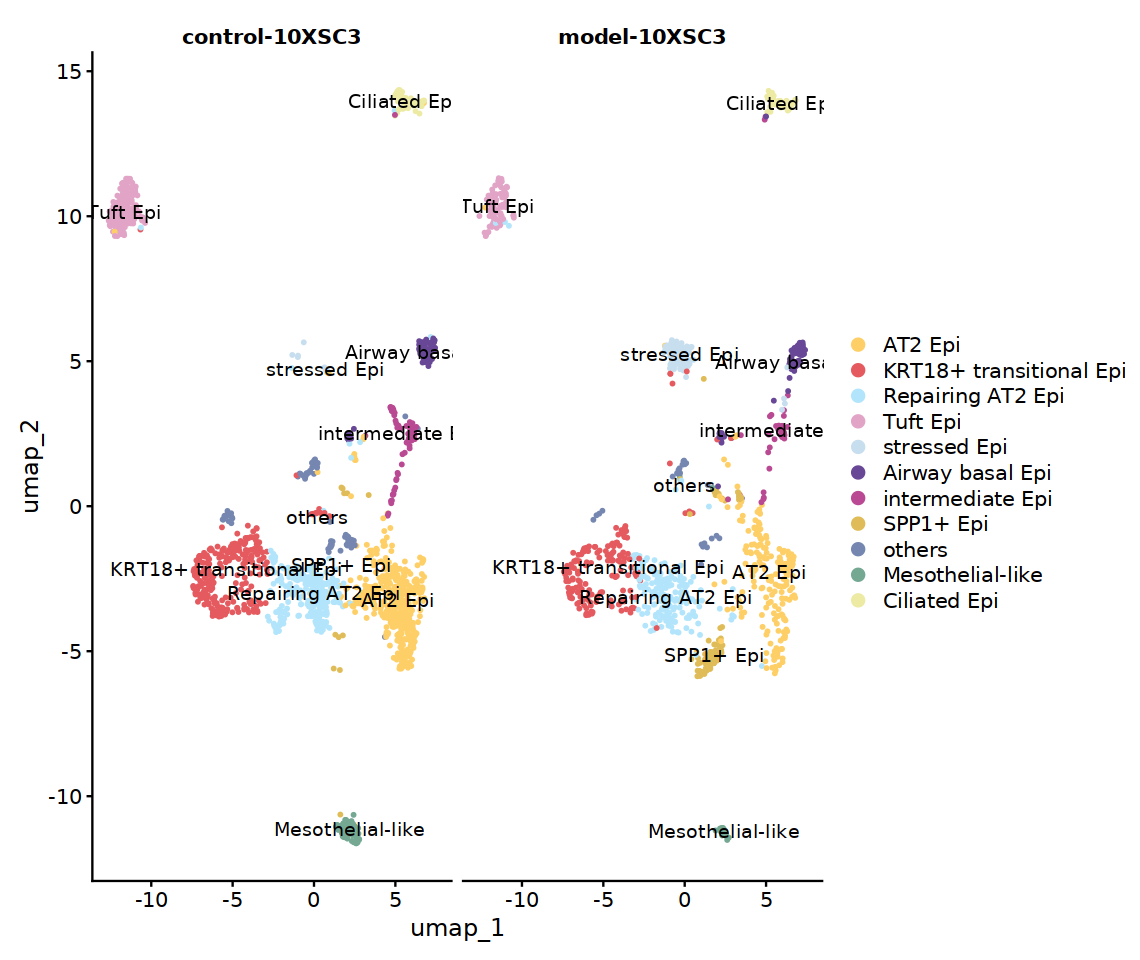

In [21]:
DimPlot(Epithelial, reduction = "umap", label = T,split.by = "orig.ident",cols =cell_colors)
ggsave("/data/work/MP/scRNA/Epithelial_subtypes_split.pdf",bg = "transparent", width =15, height =9)

In [6]:
Epithelial@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_SCT,nFeature_SCT,integrated_snn_res.0.5,seurat_clusters,total_cell_type_res_0.5,integrated_snn_res.0.1,integrated_snn_res.0.2,integrated_snn_res.0.3,integrated_snn_res.0.4,integrated_snn_res.0.6,integrated_snn_res.0.7,integrated_snn_res.0.8,integrated_snn_res.0.9,integrated_snn_res.1,integrated_snn_res.1.1,integrated_snn_res.1.2
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<fct>,<fct>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
AAACCCAAGAATGTTG-1,control-10XSC3,3413,1594,0,2532,1583,4,3,Epithelial cells,0,2,2,1,4,4,4,4,3,3,3
AAACGCTGTCGATTCA-1,control-10XSC3,3472,1386,0,2513,1374,1,0,Epithelial cells,0,2,2,1,1,1,1,1,1,1,0
AAAGGATAGCTAAGTA-1,control-10XSC3,1779,893,0,1860,893,1,0,Epithelial cells,0,2,2,1,1,1,1,1,1,1,0
AAAGGATCAGTATACC-1,control-10XSC3,3314,1401,0,2531,1386,0,4,Epithelial cells,1,0,0,0,0,0,0,0,4,4,4
AAAGGGCGTTTCTATC-1,control-10XSC3,2149,1131,0,2138,1131,2,5,Epithelial cells,0,1,1,2,2,2,2,2,5,5,5
AAAGGGCTCCGGTTCT-1,control-10XSC3,4138,1639,0,2706,1577,1,0,Epithelial cells,0,2,2,1,1,1,1,1,1,1,0
AAAGGGCTCGGCTTCT-1,control-10XSC3,9579,2535,0,2394,938,0,1,Epithelial cells,1,0,0,0,0,0,0,0,0,0,1
AAAGGGCTCGTGTCAA-1,control-10XSC3,2766,1458,0,2470,1458,3,2,Epithelial cells,2,3,3,3,3,3,3,3,2,2,2
AAAGGTAGTAATGCGG-1,control-10XSC3,1304,657,0,1670,658,2,8,Epithelial cells,0,1,1,2,2,2,2,2,7,7,8


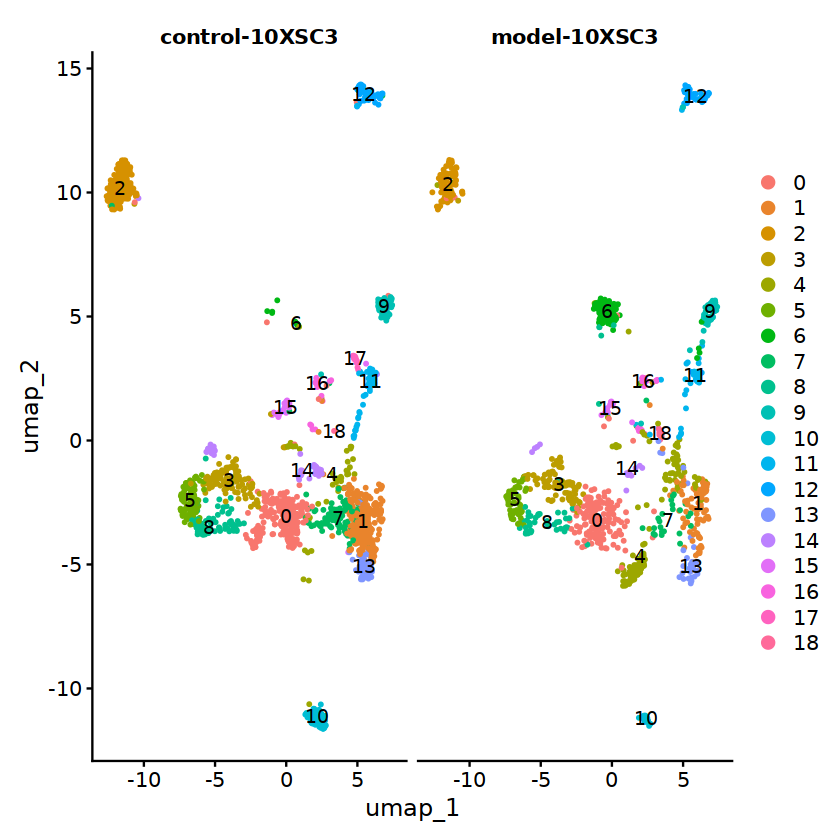

In [3]:
DimPlot(Epithelial, reduction = "umap", label = T,split.by = "orig.ident")

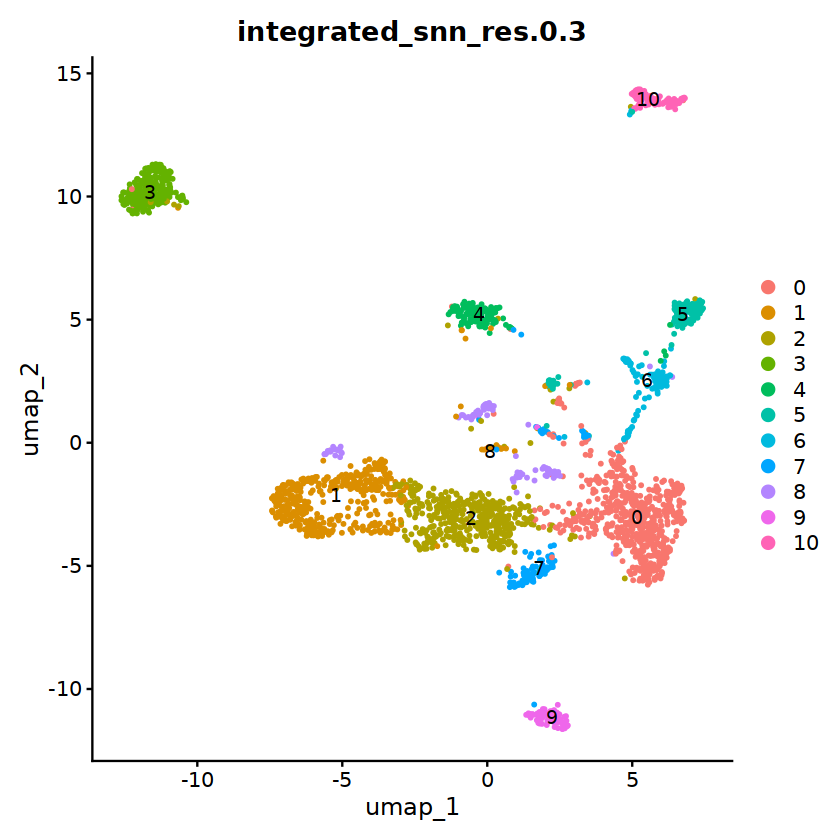

In [3]:
DimPlot(Epithelial, reduction = "umap", label = T,group.by = "integrated_snn_res.0.3")

In [4]:
Idents(Epithelial) <- Epithelial$`integrated_snn_res.0.3`
main_type_anno <- c("0"="AT2 Epi",
"1"="KRT18+ transitional Epi",
"2"="Repairing AT2 Epi",
"3"="Tuft Epi",
"4"="stressed Epi",
"5"="Airway basal Epi",
"6"="intermediate Epi",
"7"="SPP1+ Epi",
"8"="others",
"9"="Mesothelial-like",
"10"="Ciliated Epi")
                   

#names(main_type_anno) 
Epithelial <- RenameIdents(Epithelial, main_type_anno)
Epithelial$Epi_subtype_res_0.3 <- Idents(Epithelial)

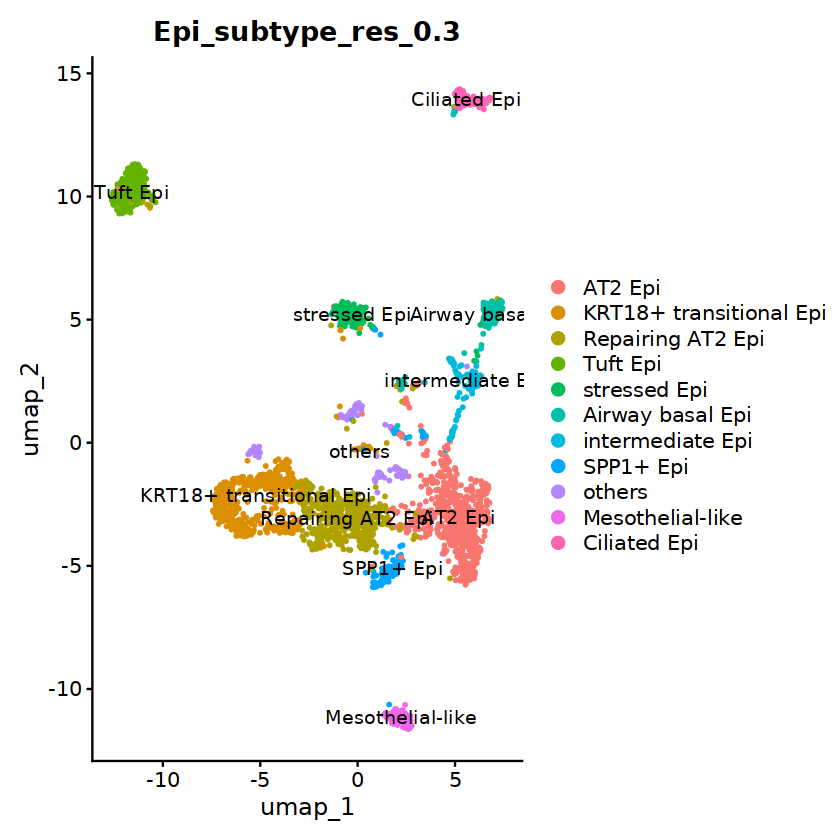

In [5]:
DimPlot(Epithelial, reduction = "umap", label = T,group.by = "Epi_subtype_res_0.3")

In [9]:
Idents(Epithelial) <- Epithelial$`Epi_subtype_res_0.3`
SPP1.markers <- FindMarkers(Epithelial, ident.1 = "SPP1+ Epi")
markers <- SPP1.markers %>%
    dplyr::filter(avg_log2FC >0.5) %>%
    dplyr::filter(p_val_adj <0.05)
write.csv(markers, file = "/data/work/MP/scRNA/SPP1+Epi_subtype_markers.csv")

In [2]:
Epithelial <- readRDS('/data/work/MP/scRNA/Epithelial_subtypes.rds')

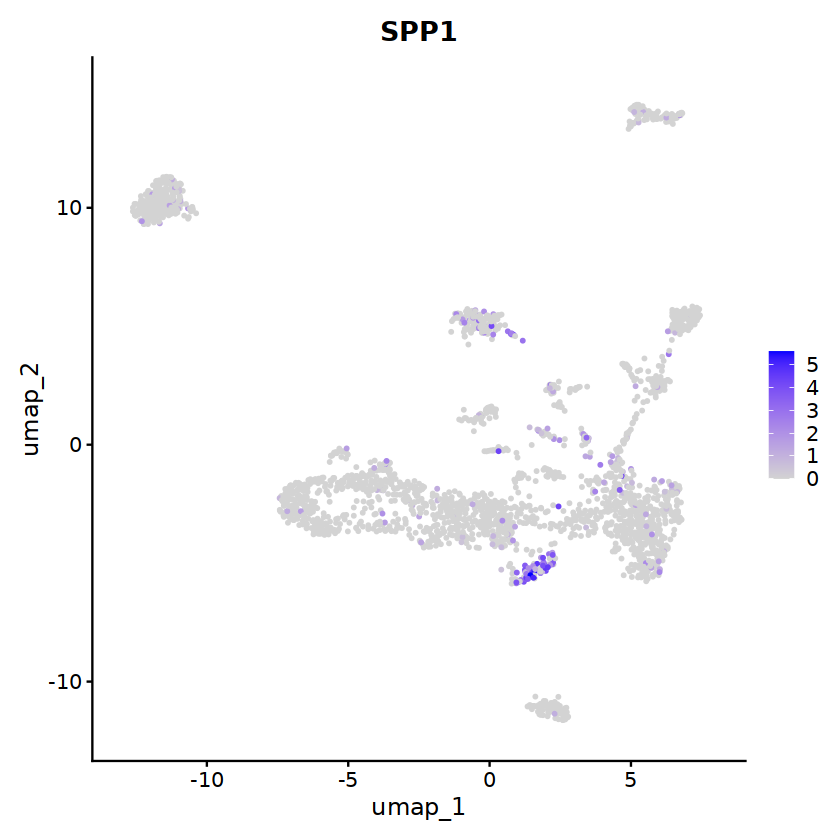

In [4]:
FeaturePlot(Epithelial, reduction = "umap", feature = "SPP1")

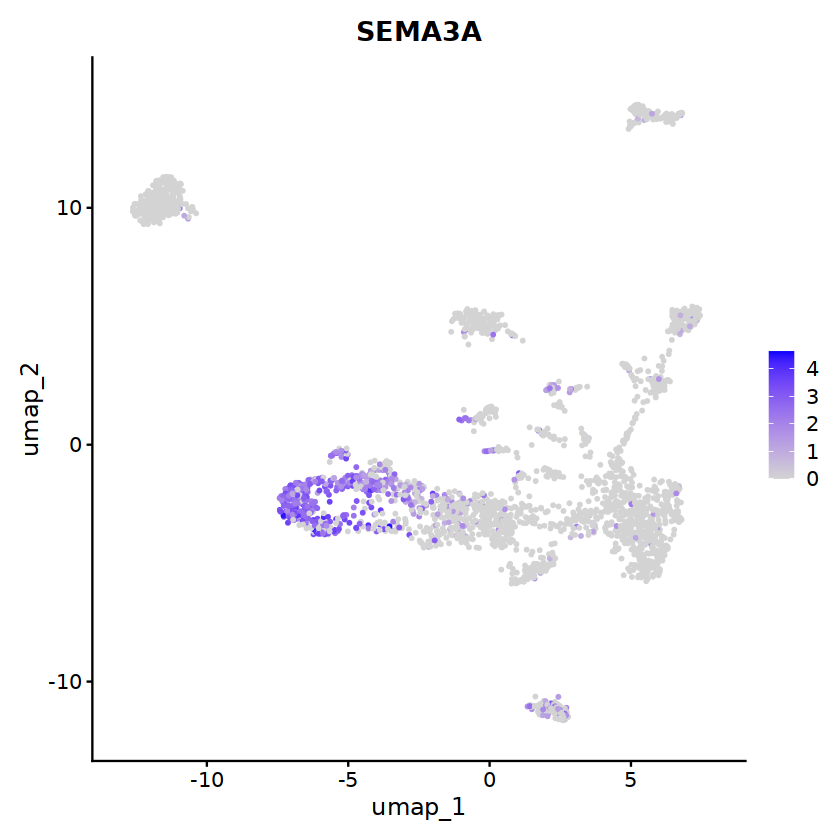

In [13]:
FeaturePlot(Epithelial, reduction = "umap", feature = "SEMA3A")

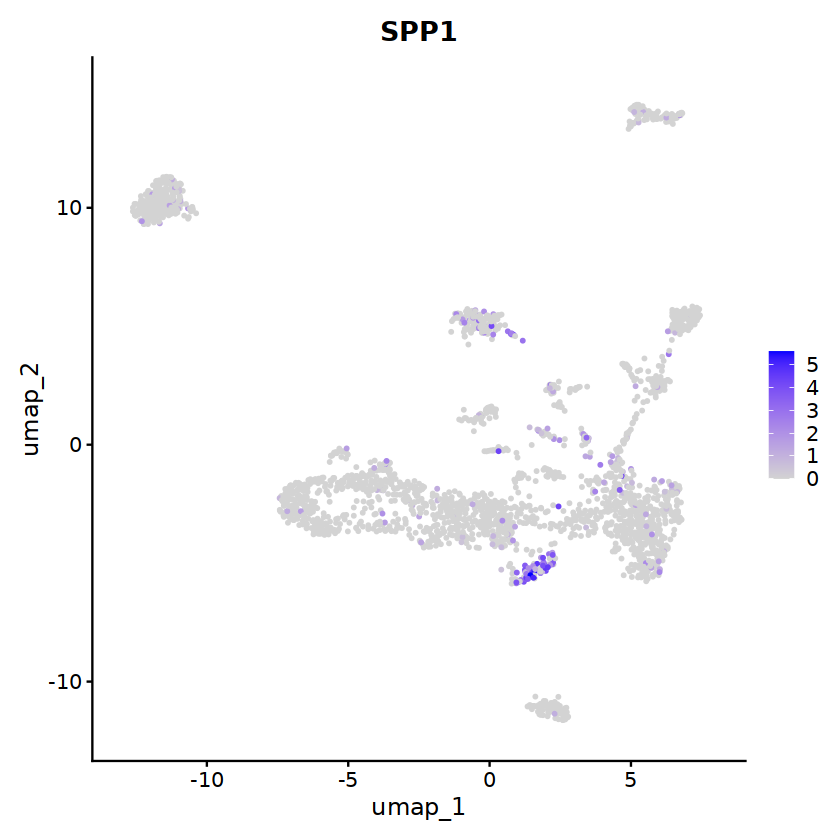

In [4]:
FeaturePlot(Epithelial, reduction = "umap", feature = "SPP1")

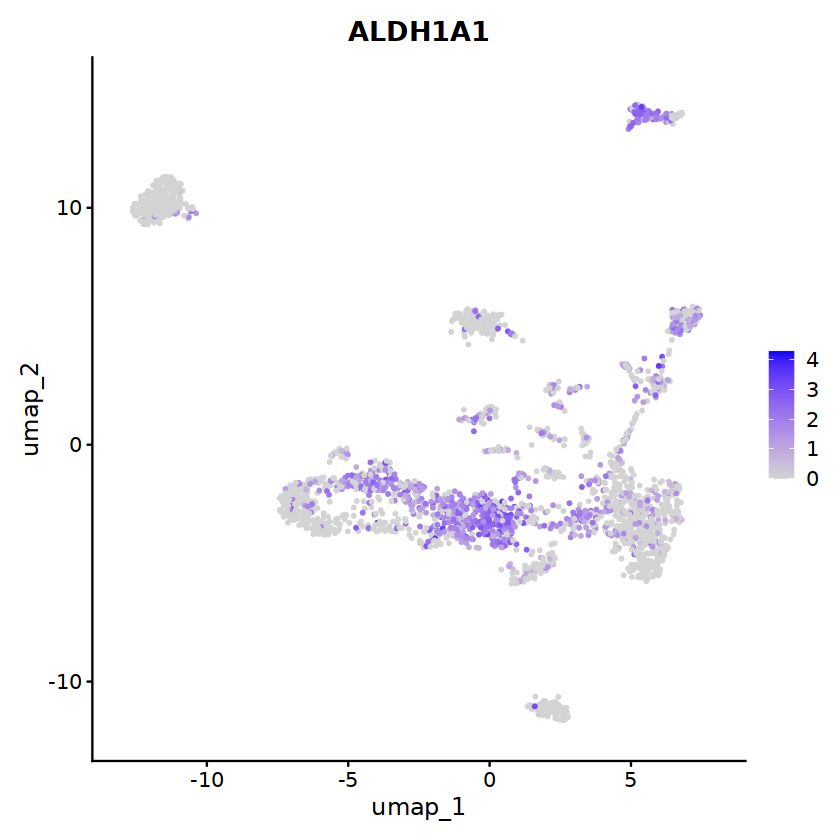

In [4]:
FeaturePlot(Epithelial, reduction = "umap", feature = "ALDH1A1")

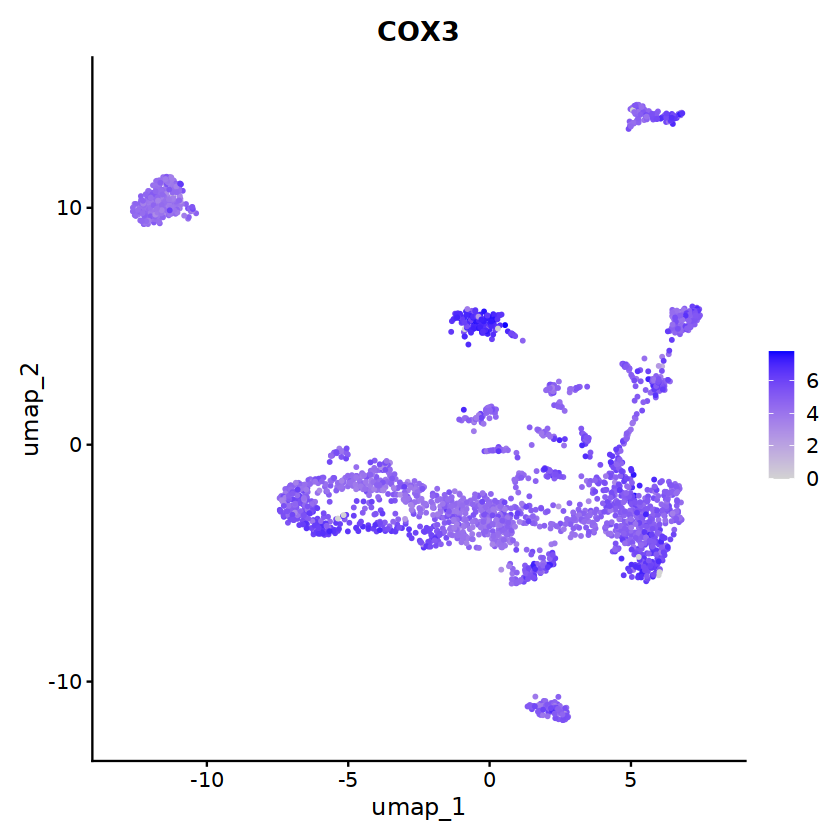

In [9]:
FeaturePlot(Epithelial, reduction = "umap", feature = "COX3")

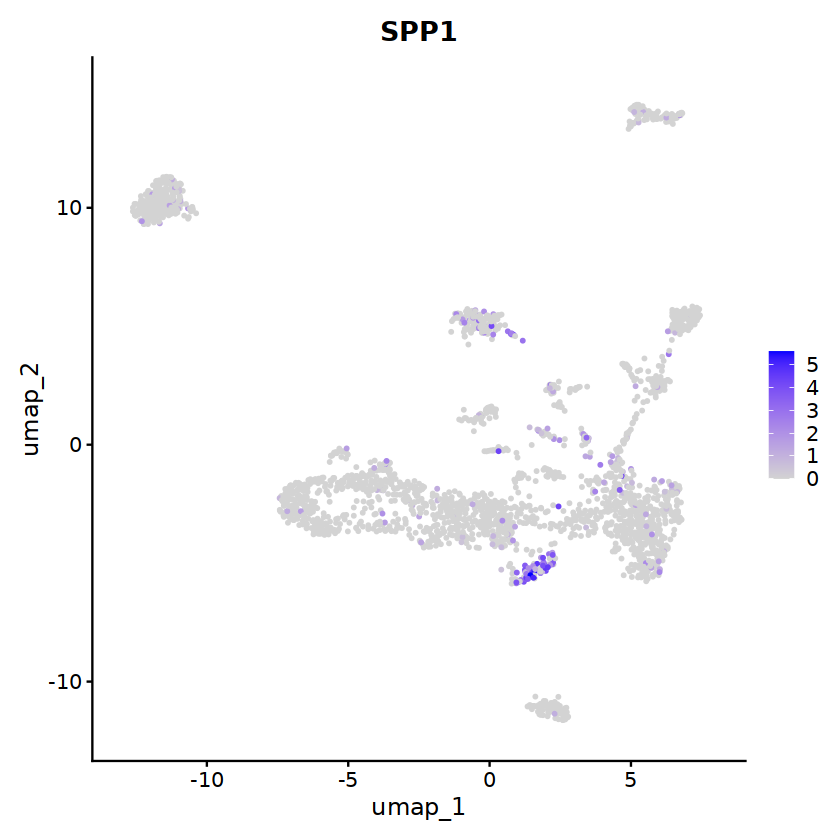

In [8]:
FeaturePlot(Epithelial, reduction = "umap", feature = "SPP1")

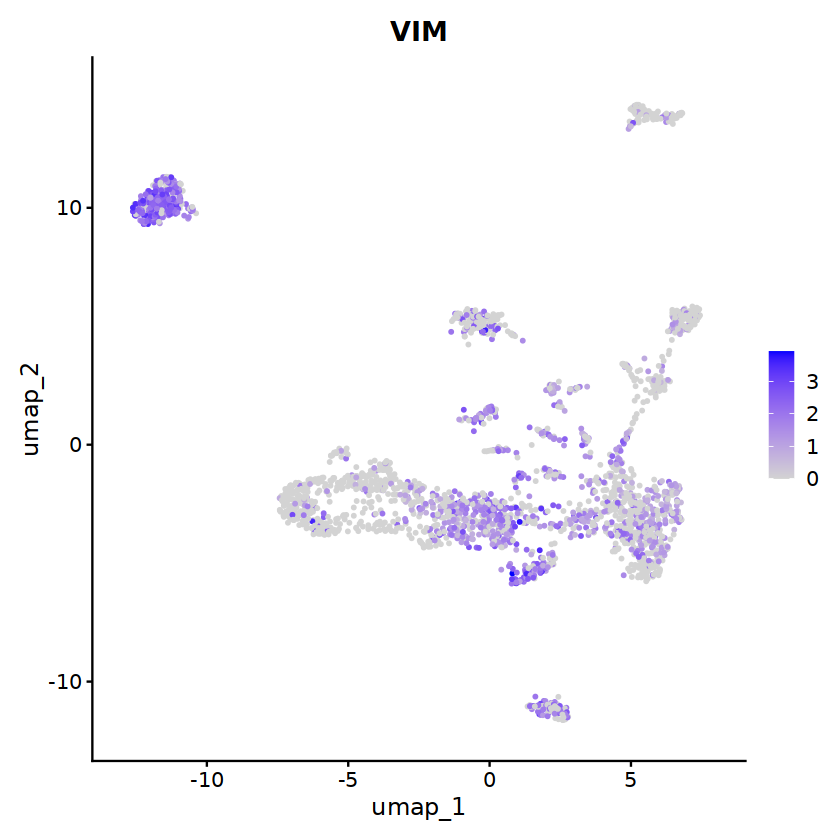

In [10]:
FeaturePlot(Epithelial, reduction = "umap", feature = "VIM")

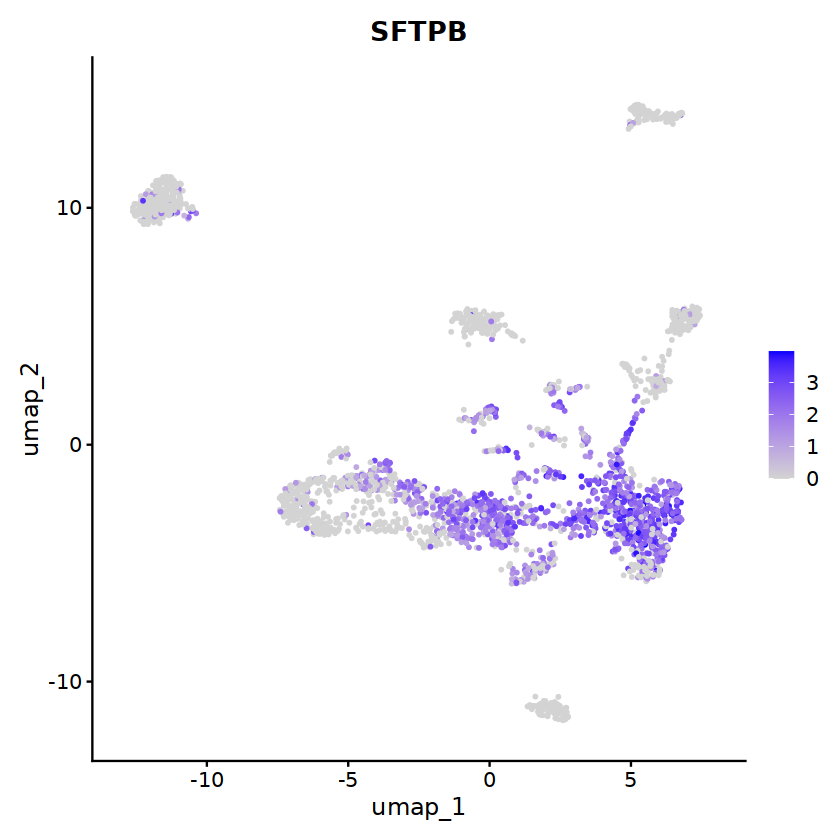

In [11]:
FeaturePlot(Epithelial, reduction = "umap", feature = "SFTPB")

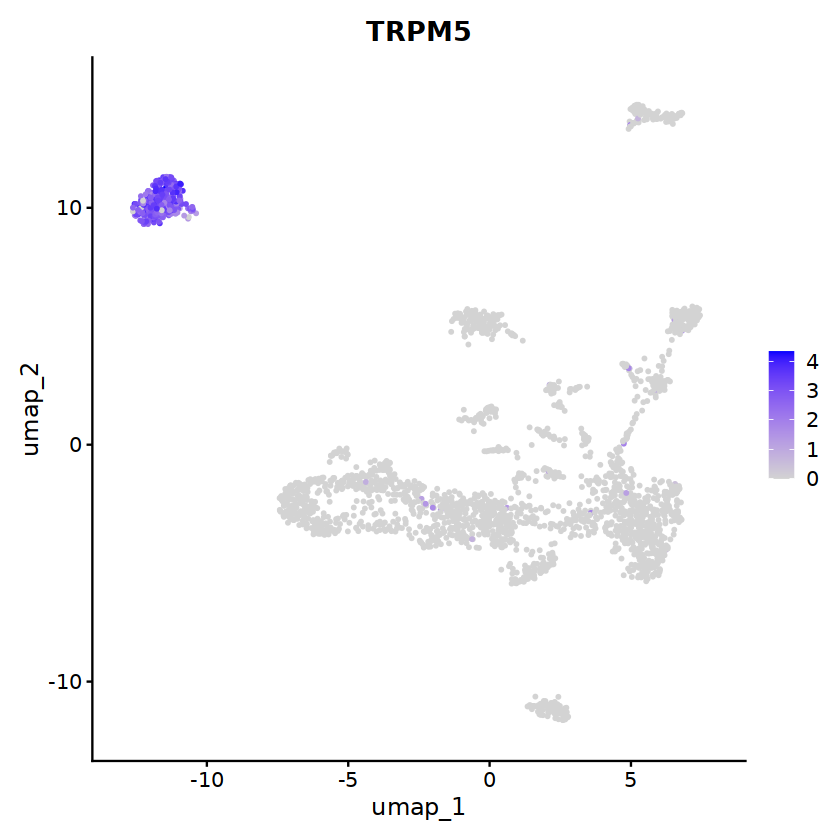

In [12]:
FeaturePlot(Epithelial, reduction = "umap", feature = "TRPM5")

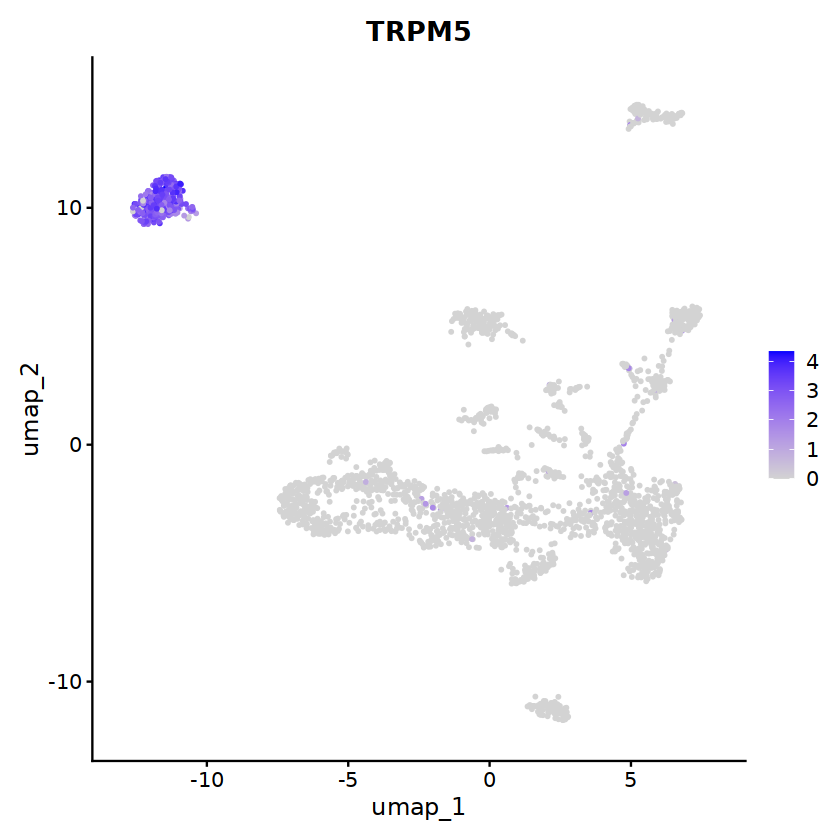

In [12]:
FeaturePlot(Epithelial, reduction = "umap", feature = "TRPM5")

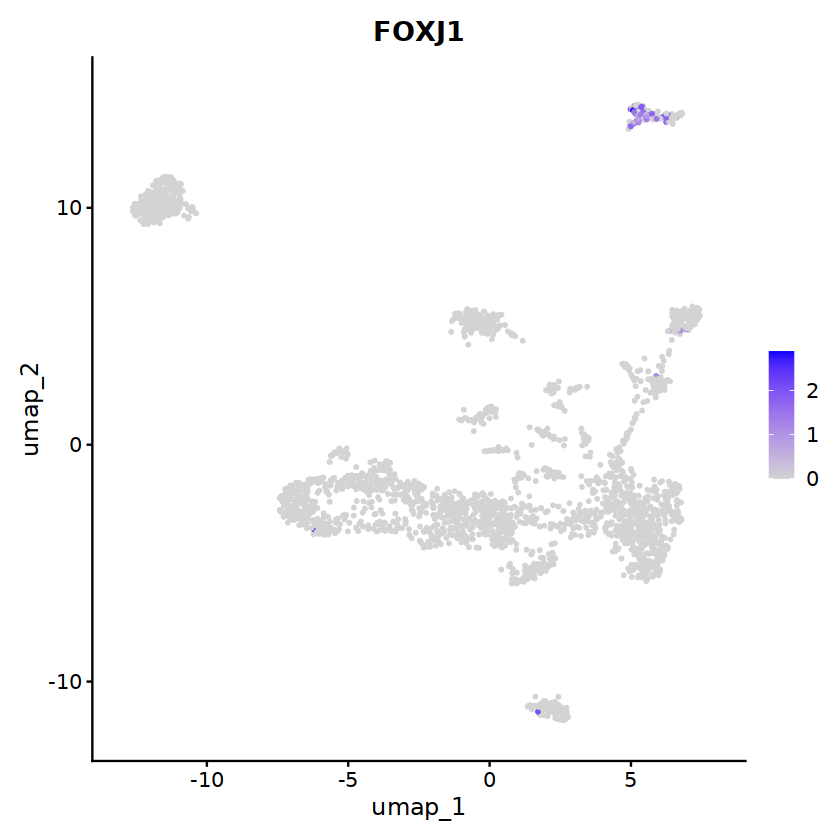

In [6]:
FeaturePlot(Epithelial, reduction = "umap", feature = "FOXJ1")

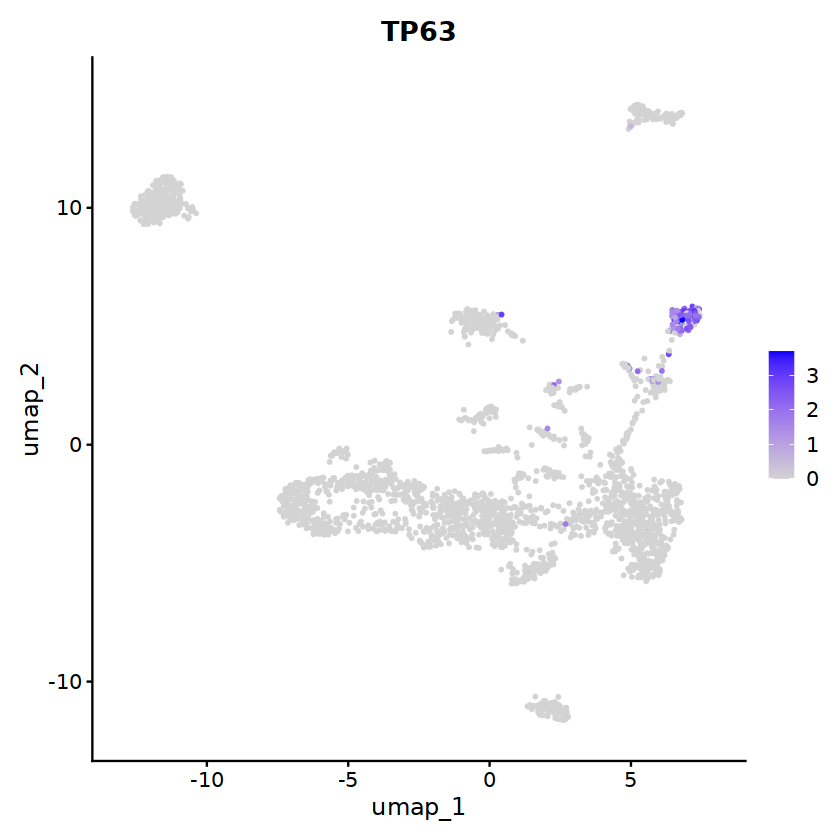

In [5]:
FeaturePlot(Epithelial, reduction = "umap", feature = "TP63")

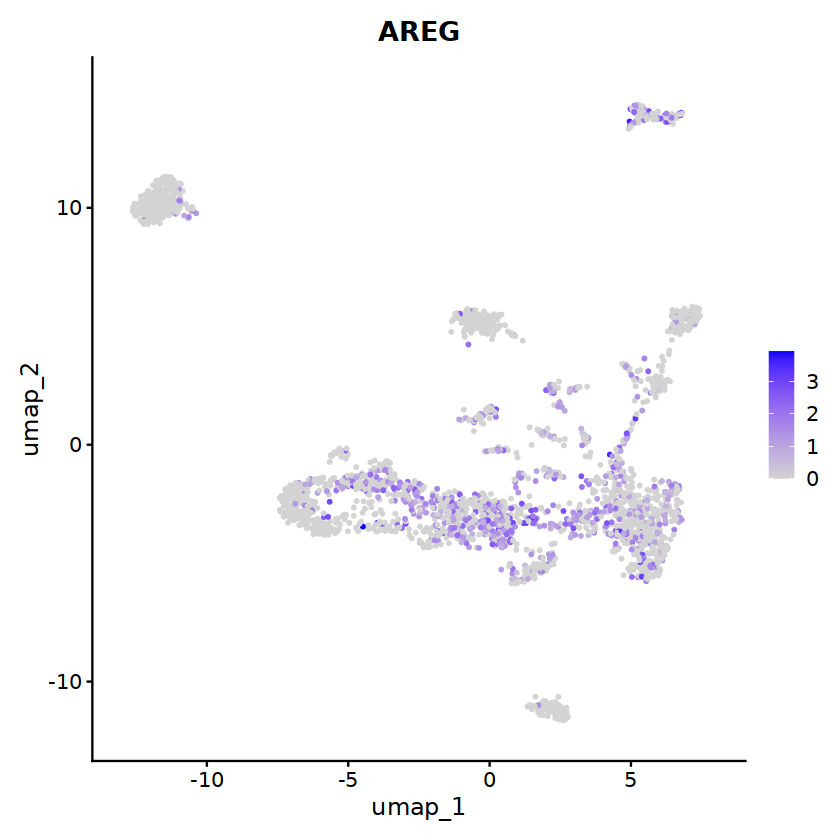

In [18]:
FeaturePlot(Epithelial, reduction = "umap", feature = "AREG")

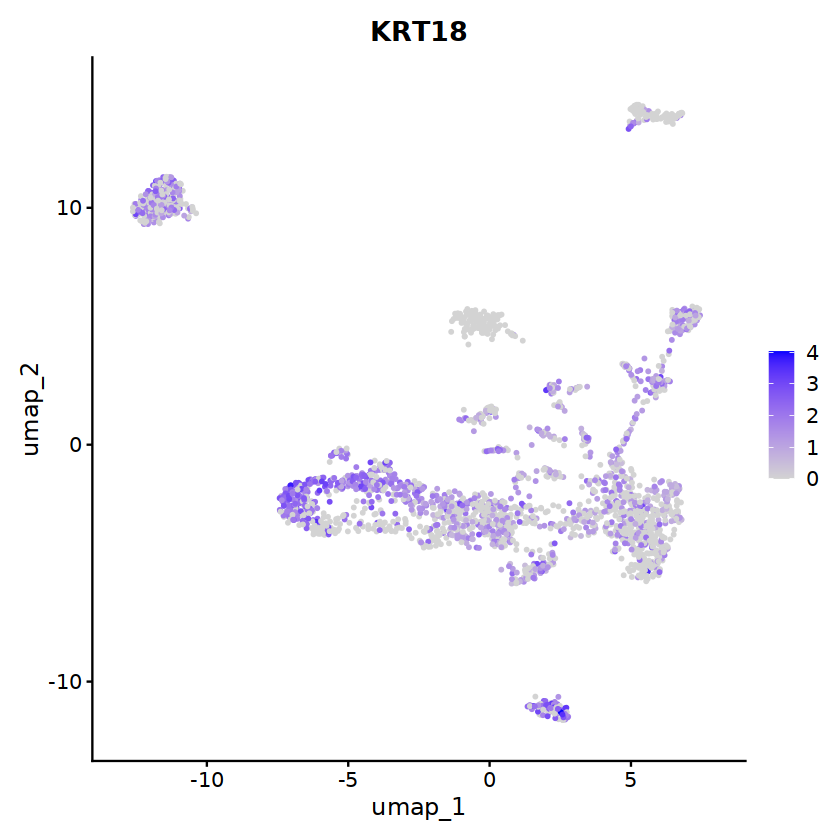

In [21]:
FeaturePlot(Epithelial, reduction = "umap", feature = "KRT18")

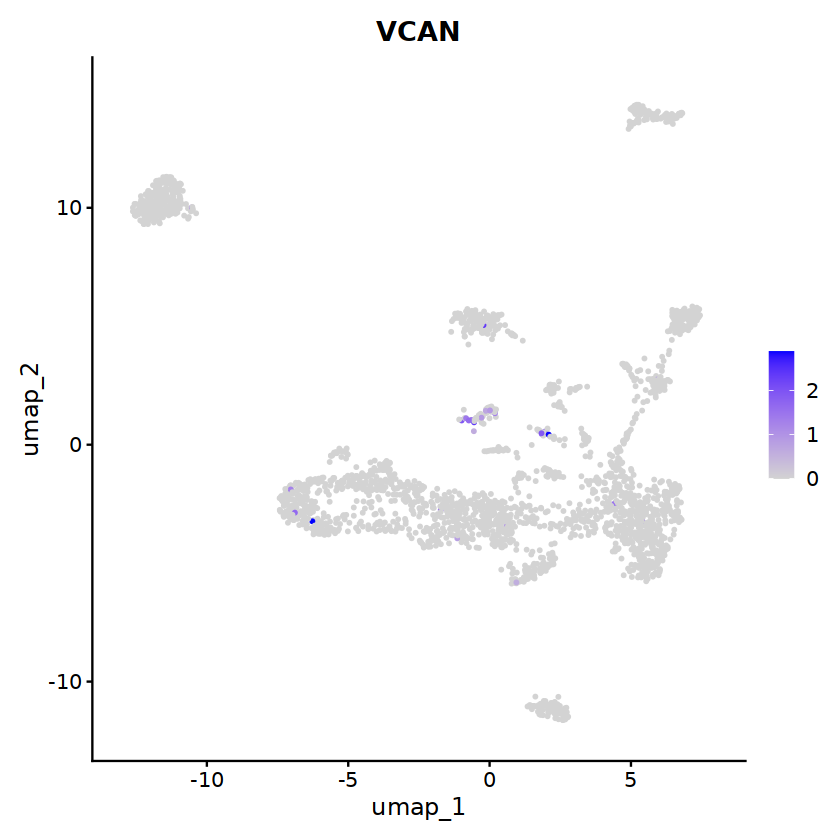

In [16]:
FeaturePlot(Epithelial, reduction = "umap", feature = "VCAN")

In [ ]:
FeaturePlot(Epithelial, reduction = "umap", feature = "VCAN")

In [62]:
Epithelial@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_SCT,nFeature_SCT,integrated_snn_res.0.5,seurat_clusters,total_cell_type_res_0.5,integrated_snn_res.0.1,⋯,integrated_snn_res.0.3,integrated_snn_res.0.4,integrated_snn_res.0.6,integrated_snn_res.0.7,integrated_snn_res.0.8,integrated_snn_res.0.9,integrated_snn_res.1,integrated_snn_res.1.1,integrated_snn_res.1.2,Epi_subtype_res_0.3
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<fct>,<fct>,<chr>,<fct>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
AAACCCAAGAATGTTG-1,control-10XSC3,3413,1594,0,2532,1583,4,3,Epithelial cells,0,⋯,2,1,4,4,4,4,3,3,3,Repairing AT2 Epi
AAACGCTGTCGATTCA-1,control-10XSC3,3472,1386,0,2513,1374,1,0,Epithelial cells,0,⋯,2,1,1,1,1,1,1,1,0,Repairing AT2 Epi
AAAGGATAGCTAAGTA-1,control-10XSC3,1779,893,0,1860,893,1,0,Epithelial cells,0,⋯,2,1,1,1,1,1,1,1,0,Repairing AT2 Epi
AAAGGATCAGTATACC-1,control-10XSC3,3314,1401,0,2531,1386,0,4,Epithelial cells,1,⋯,0,0,0,0,0,0,4,4,4,AT2 Epi
AAAGGGCGTTTCTATC-1,control-10XSC3,2149,1131,0,2138,1131,2,5,Epithelial cells,0,⋯,1,2,2,2,2,2,5,5,5,KRT18+ transitional Epi
AAAGGGCTCCGGTTCT-1,control-10XSC3,4138,1639,0,2706,1577,1,0,Epithelial cells,0,⋯,2,1,1,1,1,1,1,1,0,Repairing AT2 Epi
AAAGGGCTCGGCTTCT-1,control-10XSC3,9579,2535,0,2394,938,0,1,Epithelial cells,1,⋯,0,0,0,0,0,0,0,0,1,AT2 Epi
AAAGGGCTCGTGTCAA-1,control-10XSC3,2766,1458,0,2470,1458,3,2,Epithelial cells,2,⋯,3,3,3,3,3,3,2,2,2,Tuft Epi
AAAGGTAGTAATGCGG-1,control-10XSC3,1304,657,0,1670,658,2,8,Epithelial cells,0,⋯,1,2,2,2,2,2,7,7,8,KRT18+ transitional Epi


In [15]:
Idents(Epithelial) <- Epithelial$`integrated_snn_res.0.3`
Epithelial.markers <- FindAllMarkers(Epithelial, only.pos = TRUE)
markers <- Epithelial.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC >0.5) %>%
    dplyr::filter(p_val_adj <0.05)
write.csv(markers, file = "/data/work/MP/scRNA/Epithelial_subtype_markers.csv")

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10



In [46]:
mainmarkers <- c('SFTPB','SEMA3A','KRT18','ALDH1A1','VIM','TRPM5','COX3','TP63','SPP1','WT1','SMOC2','FOXJ1'
                 )

In [ ]:
cell_colors <- c(
'DACH2_CCN2_Ex' = '#d2e0ac',    
'SATB2_BCL6_Ex' = '#74a893',
'DACH2_MEIS2_Ex' = '#7587b1',   
'CACNA1H_SLIT1_Ex' = '#edeaa4',  
'SATB2_CCK_Ex' = '#e3d1db',
'DACH2_BDNF_Ex' = '#F19294',
'SATB2_TFAP2D_Ex' = '#C0937E',
'SATB2_KIAA1217_Ex' = '#684797',
'SATB2_SCUBE1_Ex' = '#BDA7CB',
 'SATB2_ZNF385B_Ex' = "#5EC0AD",   
'SATB2_RARB_Ex' = '#e0bc58',
'SATB2_TAC1_Ex' = '#dc8e97', 
"CACNA1H_NRP1_Ex" = "#82D4FB",
"DACH2_ZNF381_Ex" = "#FF33A1"
)

In [55]:
Idents(Epithelial) <- Epithelial$`Epi_subtype_res_0.3`
Epithelial$Epi_subtype_res_0.3 <- factor(Epithelial$Epi_subtype_res_0.3, 
                                                   levels = c(
'others',
'intermediate Epi',
'Ciliated Epi',
"Mesothelial-like",
'SPP1+ Epi',
'Airway basal Epi',
'stressed Epi',
'Tuft Epi',
'Repairing AT2 Epi',
'KRT18+ transitional Epi',
'AT2 Epi'
))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


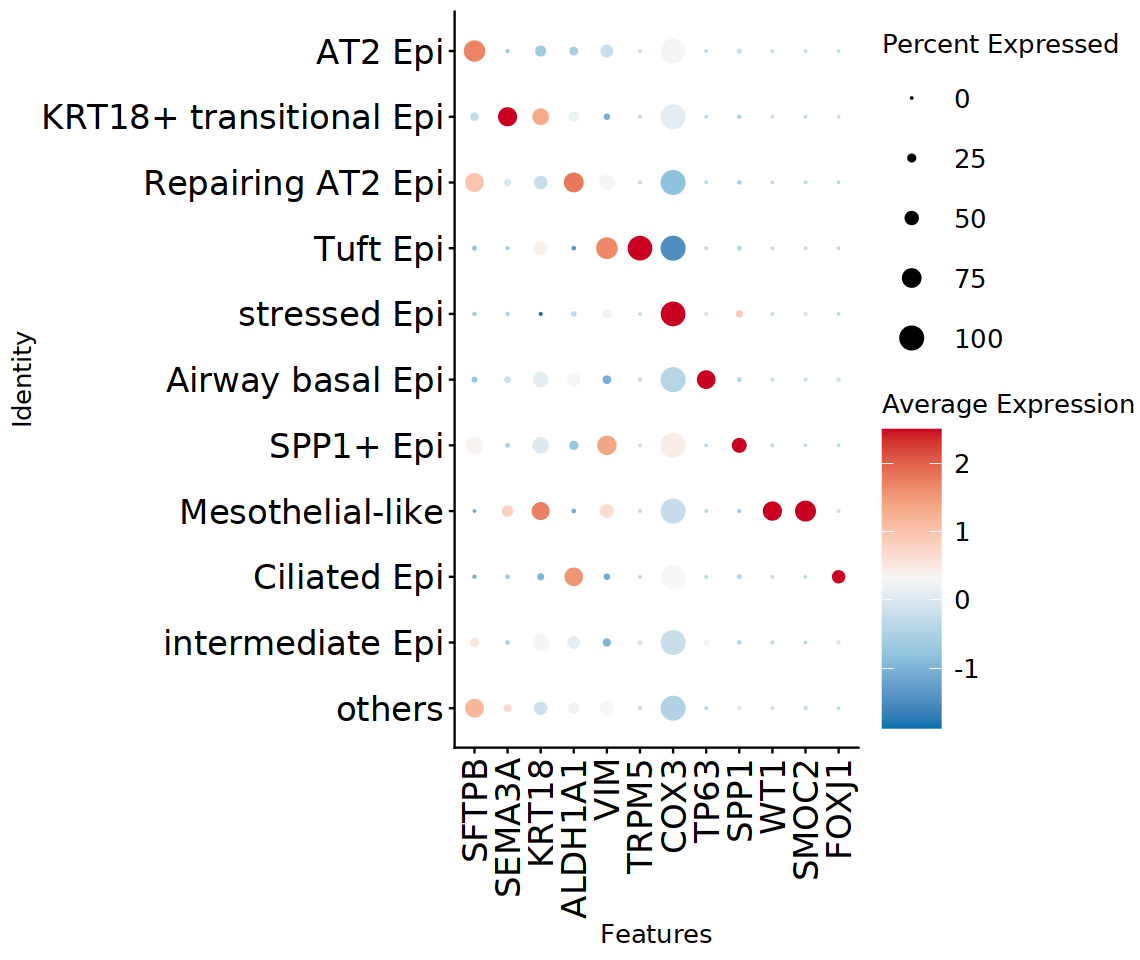

In [56]:
p <- DotPlot(Epithelial, features = mainmarkers, group.by = "Epi_subtype_res_0.3", scale = TRUE) +
  theme(axis.text = element_text(size = 20))  +
  scale_color_gradientn(colors = c('#0571b0', '#92c5de', '#f7f7f7', '#f4a582', '#ca0020')) +
  theme(text = element_text(size = 15),
        legend.text = element_text(size = 15),
        legend.key.size = unit(0.5, "inches"),
        axis.text.x = element_text(angle = 90,vjust = 0.5, hjust = 1)) 

p

In [58]:
dat <- p$data

In [51]:
library(grid)

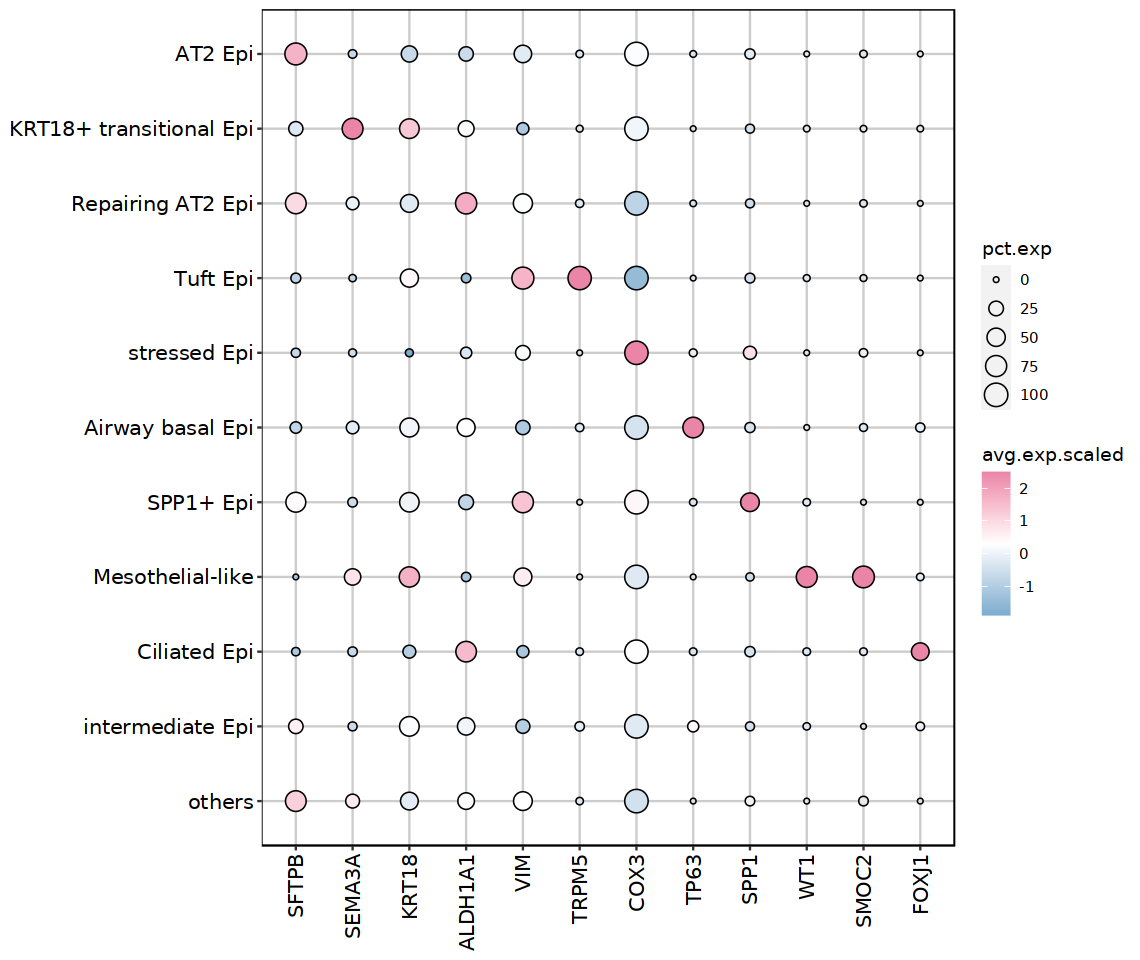

In [61]:
ggplot(dat, aes(features.plot, id,size=pct.exp, fill=avg.exp.scaled)) + 
  geom_point(shape = 21, colour="black", stroke=0.5) +
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill=NA))) + 
  theme(
    panel.background = element_blank(),
    panel.border = element_rect(fill = NA),
    panel.grid.major.x = element_line(color = "grey80"),
    panel.grid.major.y = element_line(color = "grey80"),
    axis.title = element_blank(),
    axis.text.y = element_text(color='black',size=12),
    axis.text.x = element_text(color='black',size=12, angle = 90, hjust = 1, vjust = 0.5))+
  scale_fill_gradientn(colours = c('#7CACCE', '#FFFFFF', '#EA85A8'))
ggsave("/data/work/MP/scRNA/Epithelial_subtype_markers.pdf", width = 9, height = 6)

In [63]:
library(clustree)

Loading required package: ggraph


Attaching package: ‘ggraph’


The following object is masked from ‘package:sp’:

    geometry




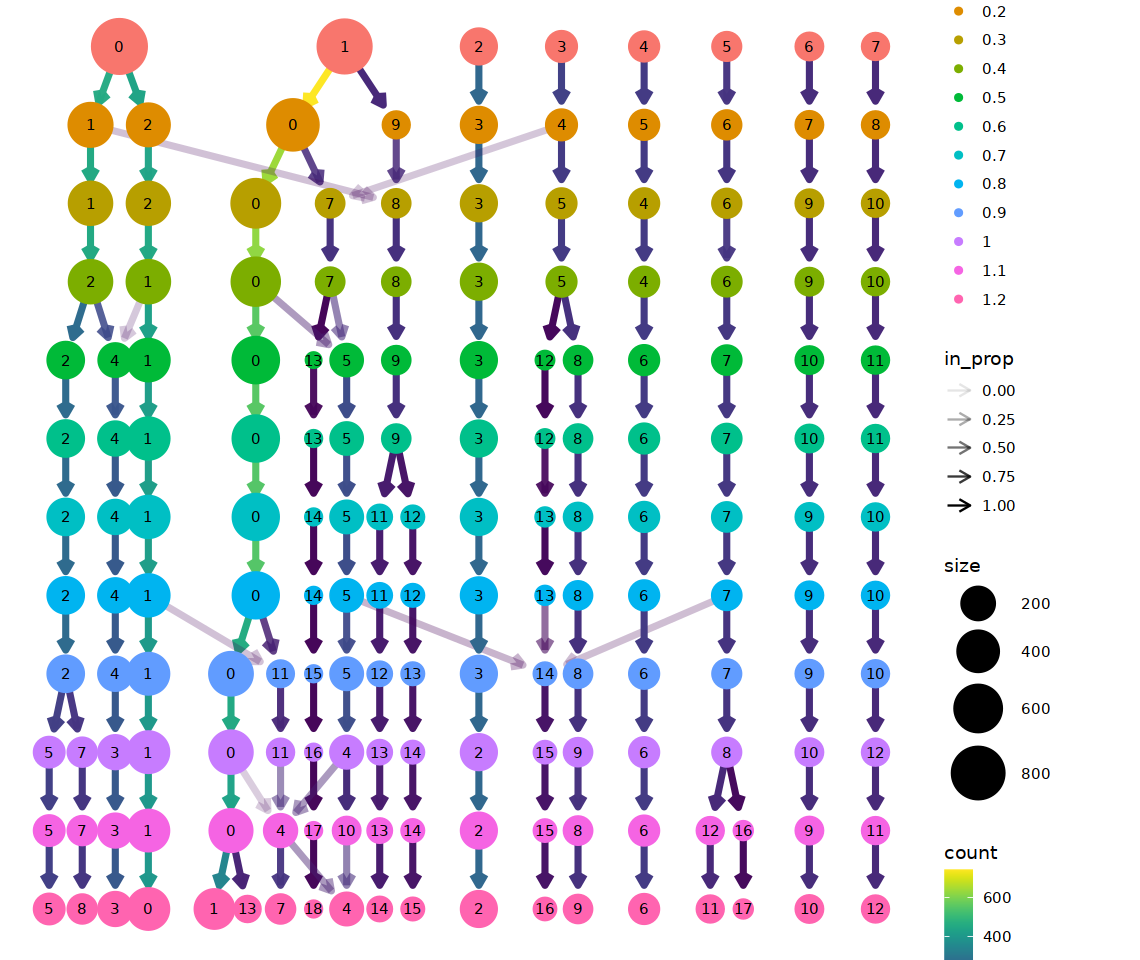

In [65]:
clustree(Epithelial@meta.data, prefix = "integrated_snn_res.")
ggsave("/data/work/MP/scRNA/Epithelial_subtype_clustree.pdf",bg = "transparent", width = 9, height = 10)